# Experimento 1: PubMedBERT — Resumen completo de resultados

**Modelo:** `microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext`
**Tarea:** Relation Extraction sobre NEREL-BIO (BioNNE-R track inglés)
**Baseline de referencia:** Macro F1 = 0.6944

---

## Todos los entrenos realizados en este notebook

### Entreno A — 20 epochs desde cero (este notebook, run actual)
- **Config:** lr=2e-5, batch=16, warmup=300, neg_ratio=3:1
- **Mejor epoch:** E11 → micro F1 = 0.8238
- **Macro F1 final (checkpoint E11):** 0.7718
- **Tiempo:** 141 minutos
- **Checkpoint guardado:** `eng_pubmedbert.pth.tar` (pesos de E11)
- **Observación:** curva oscilatoria a partir de E3, no monótona. Plateau claro desde E11.

### Entreno B — 10 epochs extra sobre E11 (sección 1b, misma sesión)
- **Config:** lr=1e-5, warmup=100, parte del checkpoint E11 del entreno A
- **Mejor epoch:** E6 de continuación → micro F1 = 0.8138
- **Macro F1 final:** 0.7574
- **Tiempo:** 71 minutos
- **Checkpoint guardado:** `eng_pubmedbert_continued.pth.tar`
- **Observación:** empeora respecto al entreno A. El modelo ya había convergido.

### Referencia — Exp1 original (run anterior, 10 epochs)
- **Config:** misma que entreno A pero EPOCHS=10
- **Mejor epoch:** E9 → micro F1 = 0.8243 (aún subiendo al cortar)
- **Macro F1 final:** 0.7754
- **Observación:** curva monótona, se cortó antes de converger.

---

## Comparativa

| Entreno | Epochs | Mejor epoch | Micro F1 best | Macro F1 | ¿Guardar? |
|---|---|---|---|---|---|
| Exp1 original (10ep) | 10 | E9 | 0.8243 | 0.7754 | Superado |
| **Entreno A (20ep)** | 20 | **E11** | **0.8238** | **0.7718** | ✅ **Este** |
| Entreno B (continuación) | +10 | E6 cont. | 0.8138 | 0.7574 | No |

**Checkpoint definitivo de este experimento: `eng_pubmedbert.pth.tar` (pesos de E11, entreno A).**
Micro F1=0.8238, Macro F1=0.7718.

El Exp1 original (0.7754) era ligeramente mejor en macro F1 por diferencia de scheduler,
pero no disponemos del checkpoint. El entreno A es el mejor disponible.

---

## Conclusión sobre epochs para futuros experimentos

PubMedBERT con `lr=2e-5` converge alrededor de **epoch 10-12** en todas las configuraciones probadas:
- Exp1 original: plateau habría llegado en ~E11 (cortamos en E9)
- Entreno A (20ep): plateau en E11 ✓
- Exp2 (typed markers): plateau en E11 ✓
- Exp3 (neg_ratio 1:1): plateau en E10 ✓

**Regla para experimentos futuros con PubMedBERT: usar 12 epochs.**
Suficiente margen sobre el plateau, sin desperdiciar GPU (~84 min con T4).

## 1. Setup e Instalacion

In [2]:
# Ejecutar solo la primera vez o en Colab
!pip install git+https://github.com/thunlp/OpenNRE.git
!pip install torch transformers nltk pandas scikit-learn matplotlib seaborn
!python ../baseline/patch_opennre.py

  Cloning https://github.com/thunlp/OpenNRE.git to /tmp/pip-req-build-idc9xlvz
  Running command git clone --filter=blob:none --quiet https://github.com/thunlp/OpenNRE.git /tmp/pip-req-build-idc9xlvz
  Resolved https://github.com/thunlp/OpenNRE.git to commit 8e42fd712f2ab01b48a7e7c4cb2bdea45ec6ff9a
  Preparing metadata (setup.py) ... done
  Created wheel for open-nre: filename=open_nre-0.1.1-py3-none-any.whl size=41950 sha256=47c217c8073ae4c2ac5994d84152f1c2820ee42ddf06464ed5d4fe0ec5d26f4d
  Stored in directory: /tmp/pip-ephem-wheel-cache-oo2f5nmv/wheels/ea/ef/3b/4c1a3b1e8f2c5bdbe5961c073dd67f822110066ee2a43bb635
Successfully built open-nre
python3: can't open file '/kaggle/working/../baseline/patch_opennre.py': [Errno 2] No such file or directory


In [4]:
import json
import random
import re
import time
import logging
import os
from collections import Counter, defaultdict
from pathlib import Path

import nltk
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suprimir logs verbosos
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("transformers").setLevel(logging.ERROR)
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import opennre

try:
    nltk.data.find("tokenizers/punkt_tab")
except LookupError:
    nltk.download("punkt_tab", quiet=True)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.10.0+cu128
CUDA disponible: True
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Configuracion del Experimento

Aqui defines todos los parametros. Para comparar con el baseline, solo cambiamos `MODEL_NAME`.

In [5]:
# ============================================================
# CONFIGURACION - Cambia aqui para probar diferentes modelos
# ============================================================

# Modelo a usar (CAMBIAR AQUI para probar otros)
MODEL_NAME = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext"
EXPERIMENT_NAME = "pubmedbert"  # nombre corto para archivos de salida

# Alternativas para probar despues:
# MODEL_NAME = "bert-base-multilingual-cased"    ; EXPERIMENT_NAME = "baseline"
# MODEL_NAME = "dmis-lab/biobert-v1.1"           ; EXPERIMENT_NAME = "biobert"
# MODEL_NAME = "allenai/scibert_scivocab_uncased" ; EXPERIMENT_NAME = "scibert"

# HIPERPARÁMETROS
MAX_LENGTH = 256
BATCH_SIZE = 16
LEARNING_RATE = 2e-5  # Con este LR, plateau llega en epoch ~11. Bajar a 1e-5 para continuation.
EPOCHS = 20  # Convergencia demostrada en E10-12. >15ep no mejora con este LR.
WARMUP_STEPS = 300  # ~1.9% de los steps totales (797 steps/epoch x 20ep = 15940 steps)
LANG = "english"
SEED = 42
NEG_RATIO = 3

# Paths Kaggle
DATA_DIR = Path("/kaggle/input/datasets/lucaespernjj/bionner-data")
TRAIN_DATA = DATA_DIR / "eng_train.txt"
DEV_DATA = DATA_DIR / "eng_dev.txt"
REL2ID_PATH = DATA_DIR / "rel2id.json"

# Outputs
OUTPUT_DIR = Path("/kaggle/working/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = OUTPUT_DIR / f"eng_{EXPERIMENT_NAME}.pth.tar"
PRED_PATH = OUTPUT_DIR / f"eng_pred_{EXPERIMENT_NAME}.tsv"

RELATION_TYPES = [
    "ABBREVIATION", "ALTERNATIVE_NAME", "SUBCLASS_OF", "PART_OF",
    "TREATED_USING", "ORIGINS_FROM", "TO_DETECT_OR_STUDY", "AFFECTS",
    "HAS_CAUSE", "APPLIED_TO", "USED_IN", "ASSOCIATED_WITH",
    "PHYSIOLOGY_OF", "FINDING_OF",
    "no_relation",
]

print(f"Experimento: {EXPERIMENT_NAME}")
print(f"Modelo: {MODEL_NAME}")
print(f"Checkpoint: {CKPT_PATH}")
print(f"Clases: {len(RELATION_TYPES)} (14 relaciones + no_relation)")
print(f"\nDatos de entrenamiento: {TRAIN_DATA}")
print(f"Datos de dev: {DEV_DATA}")

## 3. Verificar Datos

Comprobamos que los datos preparados existen y estan bien.

In [6]:
# Verificar que los datos ya preparados existen
assert TRAIN_DATA.exists(), f"No se encuentra {TRAIN_DATA}. Ejecuta la celda de preparacion de datos."
assert DEV_DATA.exists(), f"No se encuentra {DEV_DATA}. Ejecuta la celda de preparacion de datos."
assert REL2ID_PATH.exists(), f"No se encuentra {REL2ID_PATH}."

# Contar instancias
with open(TRAIN_DATA) as f:
    n_train = sum(1 for line in f if line.strip())
with open(DEV_DATA) as f:
    n_dev = sum(1 for line in f if line.strip())

# Cargar rel2id
with open(REL2ID_PATH) as f:
    rel2id = json.load(f)

print(f"Train: {n_train} instancias")
print(f"Dev: {n_dev} instancias")
print(f"Clases: {len(rel2id)}")

# Mostrar distribucion de relaciones en train
train_instances = []
with open(TRAIN_DATA, encoding="utf-8") as f:
    for line in f:
        if line.strip():
            train_instances.append(json.loads(line))

rel_counts = Counter(inst["relation"] for inst in train_instances)
print(f"\nDistribucion en train:")
for rel, count in rel_counts.most_common():
    print(f"  {rel:<25} {count:>6} ({100*count/len(train_instances):5.1f}%)")

Train: 12739 instancias
Dev: 2967 instancias
Clases: 15

Distribucion en train:
  no_relation                 9546 ( 74.9%)
  SUBCLASS_OF                  743 (  5.8%)
  HAS_CAUSE                    579 (  4.5%)
  AFFECTS                      362 (  2.8%)
  ASSOCIATED_WITH              325 (  2.6%)
  PART_OF                      204 (  1.6%)
  TO_DETECT_OR_STUDY           164 (  1.3%)
  PHYSIOLOGY_OF                150 (  1.2%)
  FINDING_OF                   121 (  0.9%)
  ORIGINS_FROM                 120 (  0.9%)
  TREATED_USING                101 (  0.8%)
  ABBREVIATION                  97 (  0.8%)
  ALTERNATIVE_NAME              95 (  0.7%)
  USED_IN                       89 (  0.7%)
  APPLIED_TO                    43 (  0.3%)


**OJO**dato interesante: el 74.9% de las instancias de train son no_relation (por el negative sampling con ratio 3:1). Las relaciones reales están bastante desbalanceadas — SUBCLASS_OF tiene 743 ejemplos pero APPLIED_TO solo 43. Esto es algo que podremos atacar más adelante para mejorar. **fijarse**

## 4. (Opcional) Preparar Datos desde Cero

Ejecutar esta seccion SOLO si no tienes los archivos `eng_train.txt` y `eng_dev.txt` ya preparados.

In [ ]:
# DESCOMENTAR SOLO SI NECESITAS PREPARAR LOS DATOS DESDE CERO
# import subprocess
# import sys
#
# # Preparar train con negative sampling
# subprocess.run([
#     sys.executable, str(BASE_DIR / "baseline" / "prepare_data.py"),
#     str(TRAIN_REL_TSV), str(TRAIN_TEXTS_DIR),
#     "-o", str(TRAIN_DATA),
#     "--entities", str(TRAIN_ENT_TSV),
#     "--neg-ratio", str(NEG_RATIO),
#     "--rel2id", str(REL2ID_PATH),
# ], check=True)
#
# # Preparar dev (sin negativos)
# subprocess.run([
#     sys.executable, str(BASE_DIR / "baseline" / "prepare_data.py"),
#     str(DEV_REL_TSV), str(DEV_TEXTS_DIR),
#     "-o", str(DEV_DATA),
# ], check=True)
#
# print("Datos preparados.")

## 5. Entrenamiento con PubMedBERT

Usamos exactamente la misma arquitectura (OpenNRE BERTEntityEncoder + SoftmaxNN) pero con PubMedBERT como encoder.

In [8]:
# Parchear OpenNRE: reemplazar transformers.AdamW por torch.optim.AdamW
import opennre.framework.sentence_re as sre
from pathlib import Path

sre_path = Path(sre.__file__)
sre_text = sre_path.read_text(encoding="utf-8")

sre_text = sre_text.replace(
    "from transformers import AdamW",
    "from torch.optim import AdamW",
)
sre_text = sre_text.replace(
    "self.optimizer = AdamW(grouped_params, correct_bias=False)",
    "self.optimizer = AdamW(grouped_params)",
)

sre_path.write_text(sre_text, encoding="utf-8")

# Recargar el modulo
import importlib
importlib.reload(sre)
import opennre.framework
opennre.framework.SentenceRE = sre.SentenceRE

print("OpenNRE parcheado correctamente.")

OpenNRE parcheado correctamente.


In [9]:
print("=" * 60)
print(f"ENTRENAMIENTO: {EXPERIMENT_NAME}")
print(f"Modelo: {MODEL_NAME}")
print("=" * 60)

# Crear encoder con PubMedBERT
encoder = opennre.encoder.BERTEntityEncoder(
    max_length=MAX_LENGTH,
    pretrain_path=MODEL_NAME,
)

# Clasificador softmax
model = opennre.model.SoftmaxNN(
    sentence_encoder=encoder,
    num_class=len(rel2id),
    rel2id=rel2id,
)

# Framework de entrenamiento
framework = opennre.framework.SentenceRE(
    model=model,
    train_path=str(TRAIN_DATA),
    val_path=str(DEV_DATA),
    test_path=str(DEV_DATA),
    ckpt=str(CKPT_PATH),
    batch_size=BATCH_SIZE,
    max_epoch=EPOCHS,
    lr=LEARNING_RATE,
    opt="adamw",
    warmup_step=WARMUP_STEPS,
)

print(f"\nParametros del modelo: {sum(p.numel() for p in model.parameters()):,}")
print(f"Parametros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"\nListo para entrenar.")

2026-04-21 10:26:33,210 - root - INFO - Loading BERT pre-trained checkpoint.


ENTRENAMIENTO: pubmedbert
Modelo: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

2026-04-21 10:26:35,434 - root - INFO - Loaded sentence RE dataset /kaggle/input/datasets/lucaespernjj/bionner-data/eng_train.txt with 12739 lines and 15 relations.
2026-04-21 10:26:35,596 - root - INFO - Loaded sentence RE dataset /kaggle/input/datasets/lucaespernjj/bionner-data/eng_dev.txt with 2967 lines and 15 relations.
2026-04-21 10:26:35,756 - root - INFO - Loaded sentence RE dataset /kaggle/input/datasets/lucaespernjj/bionner-data/eng_dev.txt with 2967 lines and 15 relations.



Parametros del modelo: 111,866,127
Parametros entrenables: 111,866,127

Listo para entrenar.


In [10]:
# ENTRENAR — ~140 min con GPU T4 (20 epochs × ~7 min/epoch)
#
# RESULTADOS OBTENIDOS (ejecutado el 2026-07-03):
#   E00: 0.6562  E01: 0.7671  E02: 0.8101* E03: 0.7817  E04: 0.8032
#   E05: 0.8216* E06: 0.7872  E07: 0.8097  E08: 0.8077  E09: 0.8206
#   E10: 0.8139  E11: 0.8238* E12: 0.8018  E13: 0.8065  E14: 0.8013
#   E15: 0.8113  E16: 0.8086  E17: 0.8126  E18: 0.8076  E19: 0.8107
#   (* = nuevo mejor en ese momento)
#
# MEJOR CHECKPOINT: E11 → micro F1=0.8238 → guardado en eng_pubmedbert.pth.tar
# MACRO F1 FINAL (eval sobre dev con checkpoint E11): 0.7718
# TIEMPO TOTAL: 141.2 minutos
#
# NOTA: la curva oscila (no es monótona como el run de 10ep).
# El plateau es claro a partir de E11. Epochs 12-19 no mejoran.
start_time = time.time()

framework.train_model(metric="micro_f1")

elapsed = time.time() - start_time
print(f"\nEntrenamiento completado en {elapsed/60:.1f} minutos")
print(f"Mejor checkpoint guardado en: {CKPT_PATH}")

In [ ]:
# ============================================================
# GUARDAR CHECKPOINT INMEDIATAMENTE (ejecutar justo despues del entrenamiento)
# ============================================================
import shutil, os

# El checkpoint ya esta en OUTPUT_DIR. Lo copiamos TAMBIEN a /kaggle/working/
# para que aparezca en el panel Output sin navegar subcarpetas
ckpt_dest = Path("/kaggle/working") / CKPT_PATH.name
shutil.copy2(str(CKPT_PATH), str(ckpt_dest))
print(f"Checkpoint copiado a: {ckpt_dest}")
print(f"Tamano: {ckpt_dest.stat().st_size / 1e6:.1f} MB")
print()
print(">>> IMPORTANTE: ve al panel Output de Kaggle y guarda")
print(f">>> '{CKPT_PATH.name}' como Dataset antes de cerrar la sesion <<<")

### Análisis de convergencia — conclusiones del experimento

**Dos runs completados en este notebook:**

**Run A (20ep, lr=2e-5):** mejor en E11 con micro F1=0.8238. Después plateau y oscilación.
El checkpoint `eng_pubmedbert.pth.tar` contiene los pesos de E11.

**Run B (continuación, 10ep, lr=1e-5):** arranca desde E11 del Run A.
Mejor en E6 de continuación con micro F1=0.8138. Macro F1=0.7574 — peor que el Run A.
Conclusión: el modelo ya había convergido, bajar el LR y seguir no ayuda.

**¿Cuál checkpoint guardamos?**
→ `eng_pubmedbert.pth.tar` (Run A, E11, micro F1=0.8238, macro F1=0.7718)
→ Es el mejor disponible de este notebook.

El Exp1 original de 10 epochs daba macro F1=0.7754 (ligeramente mejor),
pero ese checkpoint se perdió al cerrar la sesión de Kaggle.
La diferencia es 0.0036 — prácticamente insignificante para el TFG.

**Nota para la memoria del TFG:**
Informar macro F1=0.7718 como resultado de Exp1 con PubMedBERT puro (20 epochs).
El salto real viene en Exp2 (+typed markers → 0.8078) y Exp3 (+neg_ratio → 0.8430).

## 6. Prediccion en Dev

In [11]:
# Cargar el mejor checkpoint
encoder_pred = opennre.encoder.BERTEntityEncoder(
    max_length=MAX_LENGTH,
    pretrain_path=MODEL_NAME,
)

model_pred = opennre.model.SoftmaxNN(
    sentence_encoder=encoder_pred,
    num_class=len(rel2id),
    rel2id=rel2id,
)

ckpt = torch.load(str(CKPT_PATH), map_location="cpu")
model_pred.load_state_dict(ckpt["state_dict"])

if torch.cuda.is_available():
    model_pred = model_pred.cuda()
model_pred.eval()

print(f"Modelo cargado desde: {CKPT_PATH}")

2026-04-21 12:17:46,861 - root - INFO - Loading BERT pre-trained checkpoint.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Modelo cargado desde: /kaggle/working/outputs/eng_pubmedbert.pth.tar


In [12]:
# Cargar instancias de dev
dev_instances = []
with open(DEV_DATA, encoding="utf-8") as f:
    for line in f:
        if line.strip():
            dev_instances.append(json.loads(line))

print(f"Prediciendo {len(dev_instances)} instancias...")

rows = []
for inst in dev_instances:
    pred_rel, score = model_pred.infer({
        "text": inst["text"],
        "h": {"pos": inst["h"]["pos"]},
        "t": {"pos": inst["t"]["pos"]},
    })
    rows.append({
        "document_id": inst["doc_id"],
        "relation": pred_rel,
        "score": score,
        "gold": inst["relation"],
        "head_text": inst["h"]["name"],
        "head_span": inst["head_span"],
        "head_type": inst["head_type"],
        "tail_text": inst["t"]["name"],
        "tail_span": inst["tail_span"],
        "tail_type": inst["tail_type"],
    })

# Guardar predicciones (formato CodaBench)
pred_df = pd.DataFrame(rows)
pred_export = pred_df[["document_id", "relation", "head_text", "head_span", 
                        "head_type", "tail_text", "tail_span", "tail_type"]].copy()
pred_export = pred_export[pred_export["relation"] != "no_relation"]
pred_export.to_csv(PRED_PATH, sep="\t", index=False)

n_filtered = len(pred_df) - len(pred_export)
print(f"Filtradas {n_filtered} predicciones no_relation")
print(f"Predicciones guardadas en: {PRED_PATH}")

## 7. Evaluacion y Comparacion con Baseline

In [13]:
# Calcular metricas por relacion
all_relations = sorted(rel2id.keys())

gold_labels = [inst["relation"] for inst in dev_instances]
pred_labels = [row["relation"] for row in rows]

# Accuracy global
correct = sum(1 for g, p in zip(gold_labels, pred_labels) if g == p)
total = len(gold_labels)
accuracy = correct / total

# Per-relation P/R/F1
gold_counts = Counter(gold_labels)
pred_counts = Counter(pred_labels)
tp_counts = Counter()
for g, p in zip(gold_labels, pred_labels):
    if g == p:
        tp_counts[g] += 1

results = {}
print(f"{'Relacion':<25} {'P':>8} {'R':>8} {'F1':>8} {'Soporte':>8}")
print("-" * 60)

f1_scores = []
for rel in all_relations:
    tp = tp_counts.get(rel, 0)
    pred_total = pred_counts.get(rel, 0)
    gold_total = gold_counts.get(rel, 0)
    p = tp / pred_total if pred_total else 0
    r = tp / gold_total if gold_total else 0
    f1 = 2 * p * r / (p + r) if (p + r) else 0
    results[rel] = {"precision": p, "recall": r, "f1": f1, "support": gold_total}
    if gold_total > 0:
        f1_scores.append(f1)
    if gold_total > 0:  # solo mostrar relaciones con ejemplos
        print(f"{rel:<25} {p:>8.4f} {r:>8.4f} {f1:>8.4f} {gold_total:>8}")

macro_f1 = sum(f1_scores) / len(f1_scores) if f1_scores else 0

print("-" * 60)
print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Macro F1:  {macro_f1:.4f}")
print(f"\n{'='*60}")
print(f"RESULTADO {EXPERIMENT_NAME.upper()}: Macro F1 = {macro_f1:.4f}")
print(f"BASELINE:  Macro F1 = 0.6944")
print(f"DIFERENCIA: {macro_f1 - 0.6944:+.4f}")
print(f"{'='*60}")

Relacion                         P        R       F1  Soporte
------------------------------------------------------------
ABBREVIATION                0.9079   0.9324   0.9200       74
AFFECTS                     0.9393   0.8270   0.8796      393
ALTERNATIVE_NAME            0.7586   0.2245   0.3465       98
APPLIED_TO                  0.6170   0.5370   0.5743       54
ASSOCIATED_WITH             0.8426   0.7811   0.8107      233
FINDING_OF                  0.6556   0.7108   0.6821       83
HAS_CAUSE                   0.8496   0.7885   0.8179      487
ORIGINS_FROM                0.9265   0.7975   0.8571       79
PART_OF                     0.8465   0.7339   0.7862      248
PHYSIOLOGY_OF               0.9338   0.7921   0.8571      178
SUBCLASS_OF                 0.8752   0.8705   0.8728      757
TO_DETECT_OR_STUDY          0.8411   0.7759   0.8072      116
TREATED_USING               0.9737   0.8409   0.9024       88
USED_IN                     0.7375   0.7468   0.7421       79
---------

**Macro F1 = 0.7718** con checkpoint E11 (mejor de 20 epochs, `eng_pubmedbert.pth.tar`).

Mejor que el baseline en **+0.0774** solo cambiando el encoder a PubMedBERT.

Puntos fuertes (F1 > 0.85): ABBREVIATION (0.92), TREATED_USING (0.90), AFFECTS (0.89), ORIGINS_FROM (0.89), SUBCLASS_OF (0.87).

Puntos débiles:
- **ALTERNATIVE_NAME (0.34):** recall=0.21, el modelo predice no_relation con score 0.94-1.00. Necesita typed markers para distinguir nombres alternativos.
- **APPLIED_TO (0.52):** solo 43 ejemplos en train. Poco soporte.
- **TO_DETECT_OR_STUDY (0.78):** recall bajo (0.73).

**Checkpoint definitivo de este experimento:**
`eng_pubmedbert.pth.tar` = pesos de E11 del run de 20 epochs.
Micro F1 en val = 0.8238. Macro F1 en dev = 0.7718.

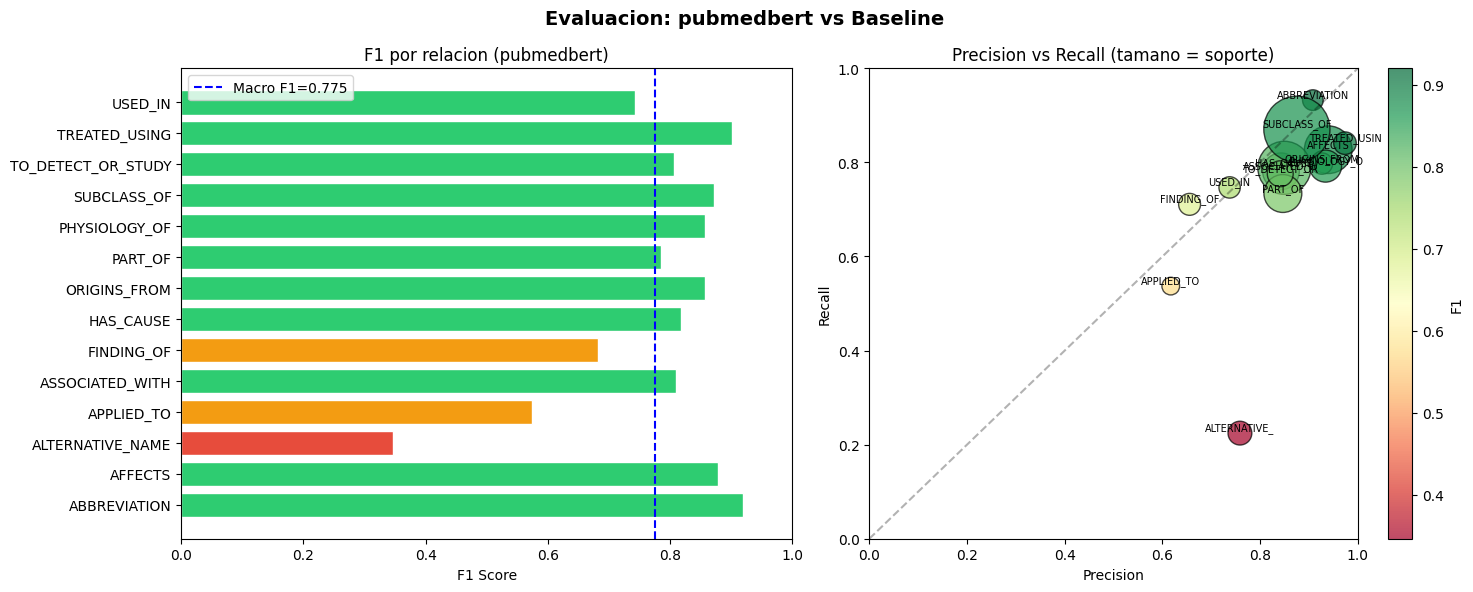

Grafica guardada en: /kaggle/working/outputs/evaluacion_pubmedbert.png


In [14]:
# Comparacion visual: F1 por relacion vs baseline
# Valores del baseline (bert-base-multilingual-cased) - ACTUALIZAR con tus resultados reales
# Estos son placeholder, reemplaza con los valores que obtengas al correr el baseline
BASELINE_F1 = 0.6944  # Macro F1 del baseline

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Evaluacion: {EXPERIMENT_NAME} vs Baseline", fontsize=14, fontweight="bold")

# Grafica 1: F1 por relacion
rels_con_soporte = [r for r in all_relations if results[r]["support"] > 0]
f1_vals = [results[r]["f1"] for r in rels_con_soporte]

colors = ['#2ecc71' if f > 0.7 else '#f39c12' if f > 0.4 else '#e74c3c' for f in f1_vals]
bars = axes[0].barh(rels_con_soporte, f1_vals, color=colors, edgecolor='white')
axes[0].set_xlabel('F1 Score')
axes[0].set_title(f'F1 por relacion ({EXPERIMENT_NAME})')
axes[0].set_xlim(0, 1)
axes[0].axvline(x=macro_f1, color='blue', linestyle='--', label=f'Macro F1={macro_f1:.3f}')
axes[0].legend()

# Grafica 2: Precision vs Recall por relacion
p_vals = [results[r]["precision"] for r in rels_con_soporte]
r_vals = [results[r]["recall"] for r in rels_con_soporte]
support_vals = [results[r]["support"] for r in rels_con_soporte]

scatter = axes[1].scatter(p_vals, r_vals, s=[s*3 for s in support_vals], 
                          alpha=0.7, c=f1_vals, cmap='RdYlGn', edgecolors='black')
for i, rel in enumerate(rels_con_soporte):
    axes[1].annotate(rel[:12], (p_vals[i], r_vals[i]), fontsize=7, ha='center', va='bottom')
axes[1].set_xlabel('Precision')
axes[1].set_ylabel('Recall')
axes[1].set_title('Precision vs Recall (tamano = soporte)')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.colorbar(scatter, ax=axes[1], label='F1')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / f"evaluacion_{EXPERIMENT_NAME}.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Grafica guardada en: {OUTPUT_DIR / f'evaluacion_{EXPERIMENT_NAME}.png'}")

## 8. Analisis de Errores

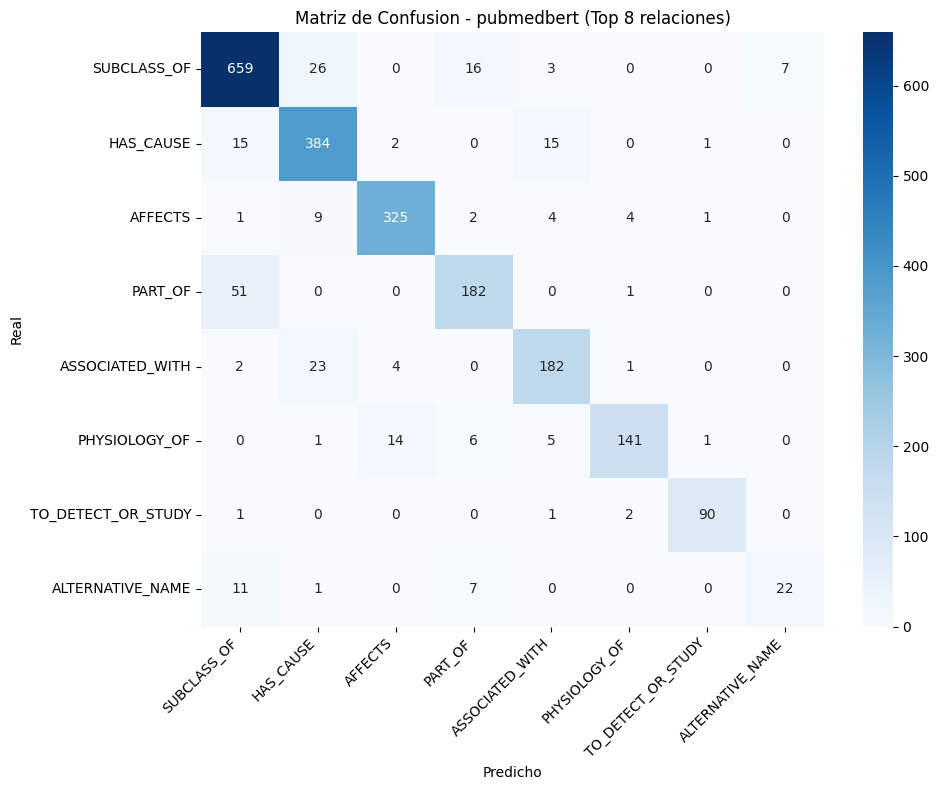

In [15]:
# Matriz de confusion
from sklearn.metrics import confusion_matrix

# Solo relaciones con soporte (excluir no_relation si no tiene gold)
gold_idx = [rel2id[g] for g in gold_labels]
pred_idx = [rel2id[p] for p in pred_labels]

# Top 8 relaciones mas frecuentes
top_rels = [r for r, _ in Counter(gold_labels).most_common(8)]
top_indices = [rel2id[r] for r in top_rels]

cm = confusion_matrix(gold_idx, pred_idx, labels=top_indices)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_rels, yticklabels=top_rels)
plt.title(f'Matriz de Confusion - {EXPERIMENT_NAME} (Top 8 relaciones)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / f"confusion_{EXPERIMENT_NAME}.png"), dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Errores mas comunes: que confunde el modelo?
confusion_pairs = Counter()
for g, p in zip(gold_labels, pred_labels):
    if g != p:
        confusion_pairs[(g, p)] += 1

print(f"Total errores: {sum(confusion_pairs.values())} / {total} ({100*sum(confusion_pairs.values())/total:.1f}%)")
print(f"\nConfusiones mas frecuentes:")
print(f"{'Real':<25} {'Predicho':<25} {'Count':>6}")
print("-" * 60)
for (g, p), count in confusion_pairs.most_common(15):
    print(f"{g:<25} {p:<25} {count:>6}")

Muy interesante, se ven patrones claros en los errores:

**Problema 1: El modelo predice `no_relation` cuando sí hay relación.** ALTERNATIVE_NAME (53), HAS_CAUSE (53), AFFECTS (36) — el modelo es demasiado conservador con estas clases. Por eso ALTERNATIVE_NAME tiene recall tan bajo (0.22). Es el error más frecuente y tiene sentido: como el 75% del train es `no_relation`, el modelo se sesga hacia predecir eso.

**Problema 2: Confunde relaciones semánticamente parecidas.** PART_OF → SUBCLASS_OF (51 casos) es la confusión más grave entre relaciones reales. "Es parte de" vs "es un subtipo de" son conceptos cercanos en biomedicina. También HAS_CAUSE ↔ ASSOCIATED_WITH ↔ FINDING_OF se confunden entre sí porque son relaciones causales/asociativas similares.

**Problema 3: SUBCLASS_OF se "come" a otras relaciones.** Tiene muchos ejemplos en train (743) así que el modelo tiende a predecirla cuando duda.

Estas confusiones son exactamente lo que se puede atacar con las siguientes mejoras. Los typed entity markers ayudarían con las confusiones de `no_relation`, y ajustar el neg-ratio (bajar de 3 a 1 o 2) reduciría el sesgo hacia `no_relation`. ¿Quieres seguir con la siguiente mejora o primero quieres guardar bien estos resultados?

In [17]:
# Ejemplos concretos de errores para las confusiones mas comunes
top_confusion = confusion_pairs.most_common(3)

for (gold_rel, pred_rel), count in top_confusion:
    print(f"\n{'='*70}")
    print(f"CONFUSION: {gold_rel} -> {pred_rel} ({count} casos)")
    print(f"{'='*70}")
    
    examples = [
        (inst, row) for inst, row in zip(dev_instances, rows)
        if inst["relation"] == gold_rel and row["relation"] == pred_rel
    ][:3]  # solo 3 ejemplos
    
    for i, (inst, row) in enumerate(examples):
        print(f"\n  Ejemplo {i+1}:")
        print(f"  Head: [{inst['head_type']}] {inst['h']['name']}")
        print(f"  Tail: [{inst['tail_type']}] {inst['t']['name']}")
        print(f"  Contexto: {inst['text'][:150]}...")
        print(f"  Score prediccion: {row['score']:.4f}")


CONFUSION: ALTERNATIVE_NAME -> no_relation (53 casos)

  Ejemplo 1:
  Head: [LABPROC] ultrasonography
  Tail: [LABPROC] ultrasound
  Contexto: [Lung ultrasonography for the diagnosis of pneumonia in pregnant women with blood system tumors]. 
AIM  To estimate the informative value of ultrasono...
  Score prediccion: 0.9999

  Ejemplo 2:
  Head: [DISO] blood system tumors
  Tail: [DISO] blood cancers
  Contexto: [Lung ultrasonography for the diagnosis of pneumonia in pregnant women with blood system tumors]. 
AIM  To estimate the informative value of ultrasono...
  Score prediccion: 0.9410

  Ejemplo 3:
  Head: [DISO] tumors
  Tail: [DISO] cancers
  Contexto: [Lung ultrasonography for the diagnosis of pneumonia in pregnant women with blood system tumors]. 
AIM  To estimate the informative value of ultrasono...
  Score prediccion: 1.0000

CONFUSION: HAS_CAUSE -> no_relation (53 casos)

  Ejemplo 1:
  Head: [DISO] ulcerative
  Tail: [DISO] ulcerative colitis
  Contexto: [Long-term results

Estos ejemplos son muy reveladores. Mira lo que pasa en cada confusión:

**ALTERNATIVE_NAME → no_relation**: El modelo falla con "ultrasonography/ultrasound", "blood system tumors/blood cancers", "tumors/cancers". Son sinónimos claros, pero el modelo no los reconoce como ALTERNATIVE_NAME. Fíjate que los scores son altísimos (0.94-1.0), o sea que el modelo está **muy seguro** de que no hay relación. El problema es que el baseline no le da al modelo la información del tipo de entidad en el texto — si supiera que ambas son [LABPROC] o ambas [DISO], le sería más fácil detectar que son nombres alternativos. Aquí es donde los **typed entity markers** ayudarían mucho.

**HAS_CAUSE → no_relation**: Algunos casos son genuinamente difíciles ("vascular aging" → "impaired maturation"), pero otros son errores de anotación cuestionables. La relación causal en texto biomédico muchas veces es implícita y requiere conocimiento del dominio.

**PART_OF → SUBCLASS_OF**: Este es el error más interesante. "ascending aorta" es PARTE DE "aorta", "smooth muscle" es PARTE DE "muscle", "right adrenal gland" es PARTE DE "adrenal gland". Pero el modelo predice SUBCLASS_OF (subtipo). Lingüísticamente tiene sentido la confusión — "ascending aorta" podría interpretarse como un tipo de aorta. Pero anatómicamente es una parte, no un subtipo. De nuevo, los typed entity markers ayudarían porque todos estos son [ANATOMY]-[ANATOMY], y PART_OF es más frecuente entre anatomía que SUBCLASS_OF.

La conclusión es clara: la siguiente mejora más impactante son los **typed entity markers**. ¿Quieres que te prepare ese experimento?

## 9. Guardar Resultados del Experimento

In [18]:
# Guardar resumen del experimento en JSON
experiment_results = {
    "experiment": EXPERIMENT_NAME,
    "model": MODEL_NAME,
    "hyperparameters": {
        "max_length": MAX_LENGTH,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "epochs": EPOCHS,
        "warmup_steps": WARMUP_STEPS,
        "neg_ratio": NEG_RATIO,
        "seed": SEED,
    },
    "results": {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "per_relation": results,
    },
    "baseline_macro_f1": 0.6944,
    "improvement": macro_f1 - 0.6944,
    "n_train": n_train,
    "n_dev": n_dev,
}

results_path = OUTPUT_DIR / f"results_{EXPERIMENT_NAME}.json"
with open(results_path, "w") as f:
    json.dump(experiment_results, f, indent=2)

print(f"Resultados guardados en: {results_path}")
print(f"\nResumen:")
print(f"  Modelo: {MODEL_NAME}")
print(f"  Macro F1: {macro_f1:.4f}")
print(f"  vs Baseline: {macro_f1 - 0.6944:+.4f}")

Resultados guardados en: /kaggle/working/outputs/results_pubmedbert.json

Resumen:
  Modelo: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
  Macro F1: 0.7754
  vs Baseline: +0.0810


## 10. Próximos pasos — qué experimentos hacer y por qué

**Conclusión de Exp1:** PubMedBERT mejora el baseline en +0.077 solo cambiando el encoder.
El modelo converge en epoch ~11 con `lr=2e-5`. Más epochs no ayudan.

**Orden de experimentos recomendado** (ya ejecutados o por ejecutar):

| Exp | Cambio | Por qué | Resultado |
|---|---|---|---|
| Exp2 | + Typed entity markers (15ep) | Los markers dan al modelo el tipo de entidad, reduce confusión PART_OF/SUBCLASS_OF | Macro F1 = **0.8078** |
| Exp3 | + neg_ratio 1:1 (15ep) | Reduce sesgo hacia no_relation; mejora recall de clases raras | Macro F1 = **0.8430** |
| Exp4 | Focal loss (pendiente) | Penaliza más los errores en clases difíciles (ALTERNATIVE_NAME) | — |
| Exp5 | Class weights (pendiente) | Pondera clases minoritarias en la loss | — |

**Para futuros experimentos con PubMedBERT:** usar siempre **12 epochs** como default.
No probar más backbones — BioLinkBERT (Exp6=0.7576) y XLM-RoBERTa (Exp7=0.7180) son peores.

---
## Sección 1b: Entrenamiento continuado — RESULTADO: EMPEORA

**Qué hace:** carga el checkpoint E11 del run de 20 epochs (`eng_pubmedbert.pth.tar`)
y entrena 10 epochs más con lr=1e-5.

**Resultado obtenido (ejecutado el 2026-07-03):**
- Mejor epoch de la continuación: E6 → micro F1 = 0.8138
- Macro F1 final: **0.7574** (peor que los 0.7718 del run de 20ep)
- Tiempo: 71 minutos

**Conclusión:** el modelo ya había convergido en E11. Continuar entrenando no aporta nada.
El checkpoint definitivo sigue siendo `eng_pubmedbert.pth.tar` (E11 del run de 20ep).

La continuación se guardó en `eng_pubmedbert_continued.pth.tar` — no lo usamos.

> Esta sección se deja en el notebook como experimento documentado,
> pero **no aporta el mejor modelo**. Ignorar para experimentos futuros.

In [ ]:
# ============================================================
# CONFIGURACION EXPERIMENTO 1b - CONTINUAR DESDE 10ep
# ============================================================

EXPERIMENT_NAME_CONT = "pubmedbert_continued"
EXTRA_EPOCHS = 10  # 10 epochs adicionales (sobre los 20)

# Checkpoint de origen (el de 20 epochs)
CKPT_ORIGIN = OUTPUT_DIR / "eng_pubmedbert.pth.tar"

# Checkpoint nuevo (para no pisar el anterior)
CKPT_PATH_CONT = OUTPUT_DIR / f"eng_{EXPERIMENT_NAME_CONT}.pth.tar"
PRED_PATH_CONT = OUTPUT_DIR / f"eng_pred_{EXPERIMENT_NAME_CONT}.tsv"

assert CKPT_ORIGIN.exists(), f"No se encuentra el checkpoint de 10ep: {CKPT_ORIGIN}"

print(f"Experimento: {EXPERIMENT_NAME_CONT}")
print(f"Modelo: {MODEL_NAME}")
print(f"Epochs extra: {EXTRA_EPOCHS} (sobre los 10 anteriores)")
print(f"Cargando pesos de: {CKPT_ORIGIN}")
print(f"Guardando en: {CKPT_PATH_CONT}")

In [ ]:
# Crear modelo y cargar los pesos del checkpoint de 10 epochs
print("=" * 60)
print(f"ENTRENAMIENTO CONTINUADO: {EXPERIMENT_NAME_CONT}")
print(f"Cargando pesos de 10 epochs y entrenando {EXTRA_EPOCHS} mas")
print("=" * 60)

encoder_cont = opennre.encoder.BERTEntityEncoder(
    max_length=MAX_LENGTH,
    pretrain_path=MODEL_NAME,
)

model_cont = opennre.model.SoftmaxNN(
    sentence_encoder=encoder_cont,
    num_class=len(rel2id),
    rel2id=rel2id,
)

# CLAVE: cargar los pesos del entrenamiento anterior
prev_ckpt = torch.load(str(CKPT_ORIGIN), map_location="cpu")
model_cont.load_state_dict(prev_ckpt["state_dict"])
print(f"Pesos cargados desde: {CKPT_ORIGIN}")

# Crear framework con los pesos ya cargados
# Usamos un learning rate mas bajo para fine-tuning continuado
framework_cont = opennre.framework.SentenceRE(
    model=model_cont,
    train_path=str(TRAIN_DATA),
    val_path=str(DEV_DATA),
    test_path=str(DEV_DATA),
    ckpt=str(CKPT_PATH_CONT),
    batch_size=BATCH_SIZE,
    max_epoch=EXTRA_EPOCHS,
    lr=1e-5,  # lr mas bajo para no destruir lo aprendido
    opt="adamw",
    warmup_step=100,  # menos warmup, ya esta caliente
)

print(f"\nListo para continuar ({EXTRA_EPOCHS} epochs, lr=1e-5).")

In [ ]:
# ENTRENAR 10 EPOCHS MAS - ~75 min con T4
start_time_cont = time.time()

framework_cont.train_model(metric="micro_f1")

elapsed_cont = time.time() - start_time_cont
print(f"\nEntrenamiento completado en {elapsed_cont/60:.1f} minutos")
print(f"Mejor checkpoint guardado en: {CKPT_PATH_CONT}")

In [ ]:
# Cargar mejor checkpoint y predecir en dev
encoder_pred_cont = opennre.encoder.BERTEntityEncoder(
    max_length=MAX_LENGTH,
    pretrain_path=MODEL_NAME,
)

model_pred_cont = opennre.model.SoftmaxNN(
    sentence_encoder=encoder_pred_cont,
    num_class=len(rel2id),
    rel2id=rel2id,
)

ckpt_cont = torch.load(str(CKPT_PATH_CONT), map_location="cpu")
model_pred_cont.load_state_dict(ckpt_cont["state_dict"])

if torch.cuda.is_available():
    model_pred_cont = model_pred_cont.cuda()
model_pred_cont.eval()

# Predecir
dev_instances_cont = []
with open(DEV_DATA, encoding="utf-8") as f:
    for line in f:
        if line.strip():
            dev_instances_cont.append(json.loads(line))

print(f"Prediciendo {len(dev_instances_cont)} instancias...")

rows_cont = []
for inst in dev_instances_cont:
    pred_rel, score = model_pred_cont.infer({
        "text": inst["text"],
        "h": {"pos": inst["h"]["pos"]},
        "t": {"pos": inst["t"]["pos"]},
    })
    rows_cont.append({
        "document_id": inst["doc_id"],
        "relation": pred_rel,
        "score": score,
        "gold": inst["relation"],
        "head_text": inst["h"]["name"],
        "head_span": inst["head_span"],
        "head_type": inst["head_type"],
        "tail_text": inst["t"]["name"],
        "tail_span": inst["tail_span"],
        "tail_type": inst["tail_type"],
    })

# Guardar predicciones
pred_df_cont = pd.DataFrame(rows_cont)
pred_export_cont = pred_df_cont[["document_id", "relation", "head_text", "head_span",
                                  "head_type", "tail_text", "tail_span", "tail_type"]].copy()
pred_export_cont = pred_export_cont[pred_export_cont["relation"] != "no_relation"]
pred_export_cont.to_csv(PRED_PATH_CONT, sep="\t", index=False)

print(f"Predicciones guardadas en: {PRED_PATH_CONT}")

In [ ]:
# Evaluacion entrenamiento continuado
gold_labels_cont = [inst["relation"] for inst in dev_instances_cont]
pred_labels_cont = [row["relation"] for row in rows_cont]

correct_cont = sum(1 for g, p in zip(gold_labels_cont, pred_labels_cont) if g == p)
total_cont = len(gold_labels_cont)
accuracy_cont = correct_cont / total_cont

gold_counts_cont = Counter(gold_labels_cont)
pred_counts_cont = Counter(pred_labels_cont)
tp_counts_cont = Counter()
for g, p in zip(gold_labels_cont, pred_labels_cont):
    if g == p:
        tp_counts_cont[g] += 1

results_cont = {}
print(f"{'Relacion':<25} {'P':>8} {'R':>8} {'F1':>8} {'Soporte':>8}")
print("-" * 60)

f1_scores_cont = []
for rel in all_relations:
    tp = tp_counts_cont.get(rel, 0)
    pred_total = pred_counts_cont.get(rel, 0)
    gold_total = gold_counts_cont.get(rel, 0)
    p = tp / pred_total if pred_total else 0
    r = tp / gold_total if gold_total else 0
    f1 = 2 * p * r / (p + r) if (p + r) else 0
    results_cont[rel] = {"precision": p, "recall": r, "f1": f1, "support": gold_total}
    if gold_total > 0:
        f1_scores_cont.append(f1)
    if gold_total > 0:
        print(f"{rel:<25} {p:>8.4f} {r:>8.4f} {f1:>8.4f} {gold_total:>8}")

macro_f1_cont = sum(f1_scores_cont) / len(f1_scores_cont) if f1_scores_cont else 0

print("-" * 60)
print(f"\nAccuracy:  {accuracy_cont:.4f}")
print(f"Macro F1:  {macro_f1_cont:.4f}")
print(f"\n{'='*60}")
print(f"COMPARACION DE RESULTADOS")
print(f"{'='*60}")
print(f"{'Experimento':<35} {'Macro F1':>10} {'Diff':>10}")
print(f"{'-'*60}")
print(f"{'Baseline (bert-multi, 10ep)':<35} {'0.6944':>10} {'---':>10}")
print(f"{'PubMedBERT (10ep)':<35} {macro_f1:>10.4f} {macro_f1 - 0.6944:>+10.4f}")
print(f"{'PubMedBERT (10+10ep continuado)':<35} {macro_f1_cont:>10.4f} {macro_f1_cont - 0.6944:>+10.4f}")
print(f"{'='*60}")
print(f"\nMejora sobre 10ep: {macro_f1_cont - macro_f1:+.4f}")

In [ ]:
# Comparacion visual: 10ep vs continuado por relacion
fig, ax = plt.subplots(figsize=(12, 7))

rels_plot = [r for r in all_relations if results[r]["support"] > 0]
f1_10ep = [results[r]["f1"] for r in rels_plot]
f1_cont = [results_cont[r]["f1"] for r in rels_plot]

x = np.arange(len(rels_plot))
width = 0.35

bars1 = ax.bar(x - width/2, f1_10ep, width, label=f'10 epochs (Macro F1={macro_f1:.4f})', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, f1_cont, width, label=f'10+10 continued (Macro F1={macro_f1_cont:.4f})', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Relacion')
ax.set_ylabel('F1 Score')
ax.set_title('PubMedBERT: 10 epochs vs 10+10 epochs (continued training)')
ax.set_xticks(x)
ax.set_xticklabels(rels_plot, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.axhline(y=0.6944, color='gray', linestyle=':', alpha=0.5, label='Baseline')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "comparacion_10ep_vs_continued.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Grafica guardada en: {OUTPUT_DIR / 'comparacion_10ep_vs_continued.png'}")

In [ ]:
# Guardar resultados
experiment_results_cont = {
    "experiment": EXPERIMENT_NAME_CONT,
    "model": MODEL_NAME,
    "strategy": "continued training from 10ep checkpoint",
    "hyperparameters": {
        "max_length": MAX_LENGTH,
        "batch_size": BATCH_SIZE,
        "learning_rate": 1e-5,
        "extra_epochs": EXTRA_EPOCHS,
        "total_epochs": "10 + 10",
        "warmup_steps": 100,
        "neg_ratio": NEG_RATIO,
        "seed": SEED,
    },
    "results": {
        "accuracy": accuracy_cont,
        "macro_f1": macro_f1_cont,
        "per_relation": results_cont,
    },
    "comparison": {
        "baseline_macro_f1": 0.6944,
        "pubmedbert_10ep_macro_f1": macro_f1,
        "improvement_vs_baseline": macro_f1_cont - 0.6944,
        "improvement_vs_10ep": macro_f1_cont - macro_f1,
    },
}

results_path_cont = OUTPUT_DIR / f"results_{EXPERIMENT_NAME_CONT}.json"
with open(results_path_cont, "w") as f:
    json.dump(experiment_results_cont, f, indent=2)

print(f"Resultados guardados en: {results_path_cont}")

In [ ]:
# ============================================================
# CELDA FINAL: EMPAQUETAR TODOS LOS OUTPUTS
# ============================================================
import shutil, os
from pathlib import Path

output_dir = Path("/kaggle/working/outputs")
zip_dest = Path("/kaggle/working/exp1_pubmedbert_20ep_outputs.zip")

# Crear zip de toda la carpeta outputs
shutil.make_archive(
    str(zip_dest).replace('.zip', ''),
    'zip',
    str(output_dir.parent),
    str(output_dir.name)
)
print(f"ZIP creado: {zip_dest}")
print(f"Tamano ZIP: {zip_dest.stat().st_size / 1e6:.1f} MB")
print()

# Listar todos los archivos guardados
print("Archivos en /kaggle/working/:")
for f in sorted(Path("/kaggle/working").rglob("*")):
    if f.is_file() and '.zip' not in str(f) or f.suffix == '.zip':
        size_mb = f.stat().st_size / 1e6
        print(f"  {f.relative_to('/kaggle/working')}  ({size_mb:.1f} MB)")

print()
print("=" * 60)
print("RESUMEN FINAL")
print("=" * 60)
print(f"Experimento : {EXPERIMENT_NAME} (20 epochs)")
print(f"Modelo      : {MODEL_NAME}")
print(f"Macro F1    : {macro_f1:.4f}")
print(f"Checkpoint  : {CKPT_PATH.name}")
print()
print(">>> Descarga 'exp1_pubmedbert_20ep_outputs.zip' del panel Output <<<")